# TD3 - ConvNets
# Pooling

### Question 1.
Get 16 images of the MNIST dataset, this dataset can be manipulated in the same way as the FashionMNIST dataset of previous TDs. It is not necessary to normalize it.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Define the transform (converting to Tensor only, no normalization as requested)
transform = transforms.Compose([transforms.ToTensor()])

# Download and load the test set
mnist_dataset = torchvision.datasets.MNIST(root='./data', train=False, 
                                           download=True, transform=transform)

# Create a DataLoader to fetch 16 images
dataloader = torch.utils.data.DataLoader(mnist_dataset, batch_size=16, shuffle=True)

# Get one batch of 16 images
data_iter = iter(dataloader)
images, labels = next(data_iter)

print(f"Batch shape: {images.shape}") # Should be [16, 1, 28, 28]

100.0%
100.0%
100.0%
100.0%

Batch shape: torch.Size([16, 1, 28, 28])


### Question 2.
Apply max pooling, average pooling and min pooling on these images. Use the torch.nn.MaxPool2d() and torch.nn.AvgPool2d() with a 3x3 filter. Note the first dimension of the inputs and outputs of the layers is the batch size. You can use the view method to change the apparent dimension of a tensor. Since minpooling is not directly implemented, you must find a way to obtain it from one the implemented pooling layers.

In [2]:
import torch.nn as nn

# 1. Prepare 16 images (Batch, Channels, Height, Width)
# Shape: [16, 1, 28, 28]
# (Assuming 'images' is your tensor of 16 MNIST samples)

# 2. Define Pooling layers with 3x3 filter
max_pool_layer = nn.MaxPool2d(kernel_size=3)
avg_pool_layer = nn.AvgPool2d(kernel_size=3)

# 3. Apply Max Pooling
out_max = max_pool_layer(images) # Result: [16, 1, 9, 9]

# 4. Apply Average Pooling
out_avg = avg_pool_layer(images) # Result: [16, 1, 9, 9]

# 5. Apply Min Pooling using -MaxPool(-x)
out_min = -max_pool_layer(-images) # Result: [16, 1, 9, 9]

# 6. Visualization using .view()
# To plot an image, we change its shape from [1, 9, 9] to [9, 9]
sample_idx = 0
original_view = images[sample_idx].view(28, 28)
max_view = out_max[sample_idx].view(9, 9)
avg_view = out_avg[sample_idx].view(9, 9)
min_view = out_min[sample_idx].view(9, 9)

### Question 3.
Using matplotlib display the 16 original images, the images after maxpoooling, after average pooling and after minpooling. In order to display several images at the same time you can use torchvision.utils.make_grid to concatenate a batch of images and display them as a grid.

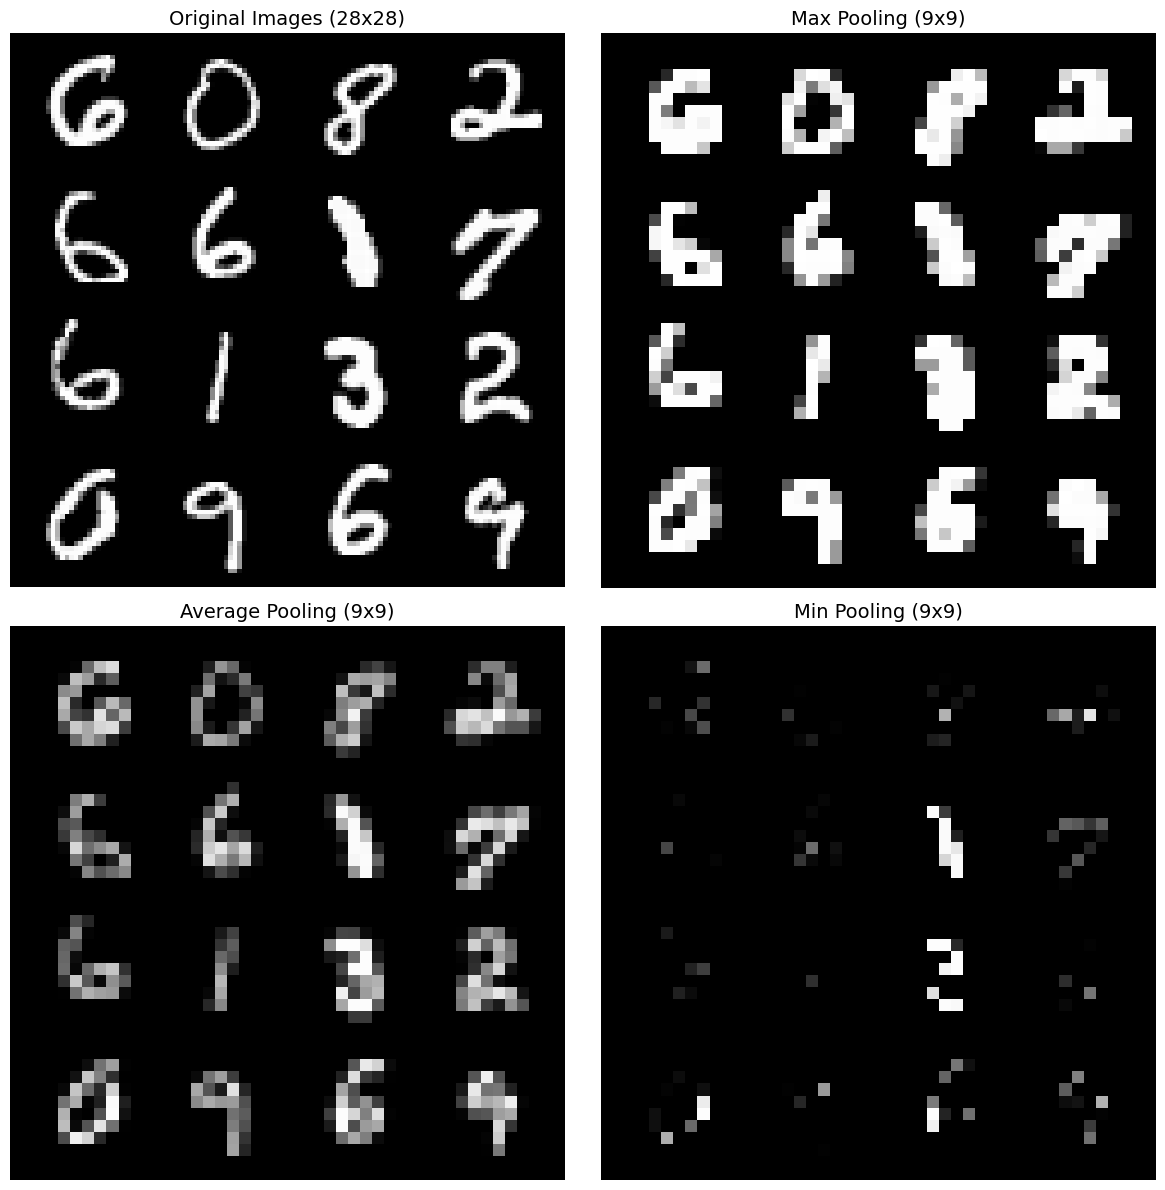

In [4]:
import torchvision.utils as vutils

# 1. Create grids using make_grid
# nrow=4 creates a 4x4 grid for our 16 images
grid_orig = vutils.make_grid(images, nrow=4, normalize=False)
grid_max  = vutils.make_grid(out_max, nrow=4, normalize=False)
grid_avg  = vutils.make_grid(out_avg, nrow=4, normalize=False)
grid_min  = vutils.make_grid(out_min, nrow=4, normalize=False)

# 2. Display using Matplotlib
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
results = [
    (grid_orig, "Original Images (28x28)"),
    (grid_max,  "Max Pooling (9x9)"),
    (grid_avg,  "Average Pooling (9x9)"),
    (grid_min,  "Min Pooling (9x9)")
]

for ax, (grid, title) in zip(axes.flat, results):
    # make_grid returns (C, H, W), Matplotlib needs (H, W, C)
    # We use .permute(1, 2, 0) to swap dimensions
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

# First CNN architectures
## Our first CNN
### Question 4.
Implement and train this network on the FashionMNIST dataset, using a kernel of size 5x5. The input images must be normalized. You will train with a 1e-3 learning rate, 5 epochs and the nn.CrossEntropyLoss() cost function. Modify the padding and the stride in order to obtain exactly the output image's sizes on the diagram.
Note that to apply a dense (linear) layer on the output of a convolutional layer, one must change the dimension of the data, you can use .view() for this.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# 1. Load and Normalize FashionMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalization as requested
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# 2. Define the Network
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        # Kernel 5x5, Padding 2 keeps 28x28 -> 28x28
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(8, 16, kernel_size=5, padding=2)
        
        self.pool = nn.MaxPool2d(2, 2) # Divides dimensions by 2
        self.relu = nn.ReLU()
        
        # After 3 rounds of Pooling (28 -> 14 -> 7 -> 3), spatial size is 3x3
        self.fc = nn.Linear(16 * 3 * 3, 10)

    def forward(self, x):
        # Layer 1: Conv -> ReLU -> Pool (28x28 -> 14x14)
        x = self.pool(self.relu(self.conv1(x)))
        # Layer 2: Conv -> ReLU -> Pool (14x14 -> 7x7)
        x = self.pool(self.relu(self.conv2(x)))
        # Layer 3: Conv -> ReLU -> Pool (7x7 -> 3x3)
        x = self.pool(self.relu(self.conv3(x)))
        
        # Flatten the tensor for the Linear layer
        x = x.view(-1, 16 * 3 * 3) 
        x = self.fc(x)
        return x

model = FashionCNN()

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    running_loss = 0.0
    for i, (images, labels) in enumerate(trainloader):
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(trainloader):.4f}")

print("Finished Training")

Epoch 1, Loss: 0.6992
Epoch 2, Loss: 0.4538
Epoch 3, Loss: 0.3947
Epoch 4, Loss: 0.3640
Epoch 5, Loss: 0.3442
Finished Training
